# Homework 1: Social Network Analysis

In [2]:
import numpy as np
import scipy.sparse as ssp
from graphLib import Graph
from itertools import combinations
import matplotlib.pyplot as plt

## Example

In [3]:
#--- read the graph file and construct a graph
graph = Graph(ssp.load_npz('../data/example_graph.npz'))

In [8]:
# number of nodes in graph:
n = graph.n
print(n)

10


In [9]:
# get the adjacency matrix of graph

A = graph.get_adj_matrix()
print(A)

[[0 0 0 0 1 0 1 1 0 0]
 [0 0 1 0 0 0 0 0 1 0]
 [0 1 0 0 0 1 1 0 0 0]
 [0 0 0 0 1 0 0 0 0 0]
 [1 0 0 1 0 1 1 0 0 1]
 [0 0 1 0 1 0 0 0 0 0]
 [1 0 1 0 1 0 0 1 0 1]
 [1 0 0 0 0 0 1 0 0 1]
 [0 1 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 0 1 1 0 0]]


In [5]:
# get adjacency list

adj_list = graph.get_adj_list()
for i in range(n):
	print(i, adj_list[i])

0 [np.int64(4), np.int64(6), np.int64(7)]
1 [np.int64(2), np.int64(8)]
2 [np.int64(1), np.int64(5), np.int64(6)]
3 [np.int64(4)]
4 [np.int64(0), np.int64(3), np.int64(5), np.int64(6), np.int64(9)]
5 [np.int64(2), np.int64(4)]
6 [np.int64(0), np.int64(2), np.int64(4), np.int64(7), np.int64(9)]
7 [np.int64(0), np.int64(6), np.int64(9)]
8 [np.int64(1)]
9 [np.int64(4), np.int64(6), np.int64(7)]


In [6]:
# get degree sequence

deg_seq = graph.get_deg_seq()
print(deg_seq)

[3 2 3 1 5 2 5 3 1 3]


## Task 1: Compute Graph Properties [45 points]

In [4]:
from task_1 import compute_deg_distr, get_cc_local, get_cc_global, get_diameter

### Task 1.1: Degree Distribution

In [42]:
#--- read the graph file and construct a graph
graph = Graph(ssp.load_npz('../data/graph_BA.npz'))

In [26]:
#--- obtain degree sequence and associated counts
degs,counts=compute_deg_distr(graph)

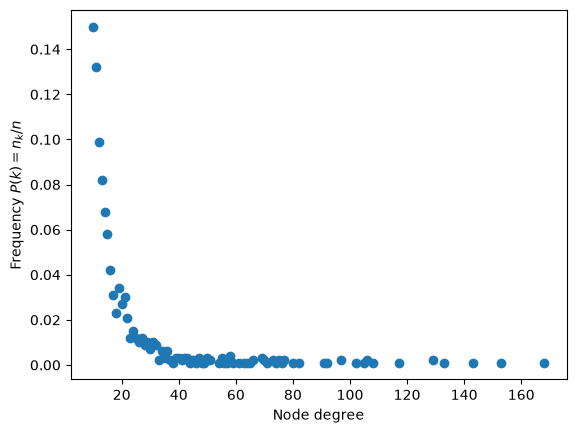

In [27]:
#--- plot the degree distribution

x = degs
y = counts/graph.n
plt.plot(x,y,'o')
plt.xlabel('Node degree')
plt.ylabel('Frequency $P(k) = n_k/n$')
plt.show()

### Task 1.2: Clustering Coefficients

In [28]:
for i in [0, 11, 24, 50, 150, 250, 334, 668]:
    print(get_cc_local(graph,i))

0.045548654244306416
0.06458511548331908
0.05669710806697108
0.0701344243132671
0.06333333333333334
0.05533596837944664
0.08496732026143791
0.13333333333333333


In [29]:
cc_global = get_cc_global(graph)

In [30]:
print(cc_global)

0.056632348530516616


### Task 1.3: Graph Diameter

In [37]:
diameter = get_diameter(graph)

In [38]:
print(diameter)

2


## Task 2: Compute Node Centralities [35 points]

In [39]:
from task_2 import get_eigen_centrality, build_matrix, get_btw_c

### Task 2.1: Eigenvector Centrality

In [5]:
# TODO: find the top-10 nodes and their eigenvector centralities

In [43]:
eigenvector = get_eigen_centrality(graph)

### Task 2.2: Betweenness Centrality

In [ ]:
# build 2 global matrices: a distance matrix, and a matrix storing the number of shortest pathes
n = graph.n
distance_mat = np.zeros((n,n), dtype = int)
num_shortest_path_mat = np.zeros((n,n), dtype = int)

In [45]:
# construct the two matrices - it is recommended you save the two matrices into files since they 
# take a lot of time to compute 
build_matrix(graph,distance_mat,num_shortest_path_mat)

In [51]:
print(n)

# TODO: compute the betweenness centrality for each node
btw_c = np.zeros(n, dtype=float)
for i in range(n):
    btw_c[i] = get_btw_c(graph, i, distance_mat, num_shortest_path_mat)
    print(i)
    print(btw_c[i])

# top 10 nodes
top_10 = np.argsort(btw_c)[::-1][:10]
print(top_10)

# top 10 with centralities
for rank, node in enumerate(top_10, 1):
    print(rank, int(node), btw_c[node])

1000
0
0.01140901125963014
1
0.01131135369162599
2
0.001670505391507073
3
0.007025089594715515
4
0.02267382478115023
5
0.0216867202831611
6
0.015664618853158424
7
0.024061778986845295
8
0.005852195664190248
9
0.012202150261422622
10
0.046522545141998335
11
0.050967377847252464
12
0.033243884538509905
13
0.03472013802571343
14
0.04310592537042507
15
0.02377614847246684
16
0.020395649281311108
17
0.03669015661015354
18
0.021450451078975617
19
0.01792295832327866
20
0.009865241430152842
21
0.028451953088224232
22
0.009650643044099417
23
0.024647156742300953
24
0.011791174945229238
25
0.013091828594629283
26
0.01927972674338925
27
0.004750591947357919
28
0.011591892196888831
29
0.01107788238567999
30
0.007768521051012342
31
0.013434889580477376
32
0.006971955454509171
33
0.012170540468930768
34
0.01307432949441445
35
0.004790847692588986
36
0.006275152708567612
37
0.013874047482768876
38
0.00978971251955808
39
0.0058244368371768475
40
0.00802070342172162
41
0.004884827894701012
42
0.013418

In [ ]:
print(n)

eig_c = get_eigen_centrality(graph)

top_10 = np.argsort(eig_c)[::-1][:10]
print(top_10)

# top 10 with centralities
for rank, node in enumerate(top_10, 1):
    print(rank, int(node), eig_c[node])

1000
[11 10 14 13 12 17 15 21 18  4]
1 11 0.050967377847252464
2 10 0.046522545141998335
3 14 0.04310592537042507
4 13 0.03472013802571343
5 12 0.033243884538509905
6 17 0.03669015661015354
7 15 0.02377614847246684
8 21 0.028451953088224232
9 18 0.021450451078975617
10 4 0.02267382478115023


In [46]:
# compute centrality for node 0 (this is just an example)
centrality = get_btw_c(graph,5,distance_mat,num_shortest_path_mat)

## Task 3: Link Prediction [20 points]

In [6]:
from task_3 import gen_net_obs, compute_Jaccard, compute_Katz, link_pred

graph = Graph(ssp.load_npz('../data/ws_graph.npz'))

# load the test edges and non_edges
test_edges = np.loadtxt('../data/target.edges',dtype = int)
test_non_edges = np.loadtxt('../data/target.nonedges', dtype = int)
pos_num = len(test_edges)
neg_num = len(test_non_edges)

# 1 denotes an edge; 0 denotes a non-edge
ground_truth = np.concatenate((np.ones(pos_num,dtype = int),np.zeros(neg_num,dtype = int)), axis = 0)

In [ ]:
# TODO: generate observed network

In [7]:
adj_obs, test_set = gen_net_obs(graph, test_edges,test_non_edges)

In [ ]:
# TODO: Get similarity based on metric (Katz or Jaccard)

In [8]:
jaccardsim = compute_Jaccard(adj_obs,test_set)
np.savetxt('../result/Jac_sim.txt', jaccardsim, fmt = '%f')

In [9]:
katzsim = compute_Katz(adj_obs,test_set)
np.savetxt('../result/Katz_sim.txt', katzsim, fmt = '%f')

In [ ]:
# TODO: make prediction

In [10]:
pred_jac=link_pred(adj_obs, test_set, 'Jaccard',0.1)
pred_katz=link_pred(adj_obs, test_set, 'Katz',0.02)

In [ ]:
# TODO: compute accuracy based on pred and groundtruth
# accuracy  =  correctly predicted node pairs/total number of pairs
acc_jac = 0

In [ ]:
acc_katz = 0

## Task 4: Generate Random Graphs [20 points]

### Task 4.1: Erdos-Renyi Graph [10 points]

In [ ]:
from task_4 import gen_ER, gen_BA

In [ ]:
# parameters - DO NOT CHANGE the seed
seed = 14
n = 200
p = 0.2
m = 5

# TODO: get the adj matrix A for erdos-renyi graphs
A_ER = gen_ER(n,p,seed)

# save the matrix A into file
ssp.save_npz('../result/task_4_graph_ER.npz', ssp.csr_matrix(A))

In [ ]:
degs_sorted = np.sort(sum(A_ER))

plt.plot(range(len(degs_sorted)),degs_sorted,'bo')
plt.ylabel('Degrees')
plt.show()

### Task 4.1: Erdos-Renyi Graph [10 points]

In [ ]:
# TODO: get the adj matrix A for BA graphs
A_BA = gen_BA(n,m,seed)

# save the matrix A into file
ssp.save_npz('../result/task_4_graph_BA.npz', ssp.csr_matrix(A))

### Task 4.2: Erdos-Renyi Graph [10 points]

In [ ]:
degs_sorted = np.sort(sum(A_BA))

plt.plot(range(len(degs_sorted)),degs_sorted,'bo')
plt.ylabel('Degrees')
plt.show()

## Task 5: Influence Maximization and Blocking [30 points]

In [ ]:
# parameters: DO NOT CHANGE
p = 0.05
mc = 5000
#k=10
k = 1

In [ ]:
from task_5 import greedySearch, modify_graph

In [ ]:
graph = Graph(ssp.load_npz('../data/example_graph.npz'))
#graph = Graph(ssp.load_npz('../data/BA_graph_100.npz'))

In [ ]:
seeds, influence = greedySearch(graph,k,p,mc)

In [ ]:
# we recommend saving the results into files
#np.savetxt('../result/IM_seeds.txt', seeds, fmt = '%s')
#np.savetxt('../result/IM_influence.txt', influence, fmt = '%f')

# uncomment these lines if you want to read the values instead of recalculating them 
# seeds = np.loadtxt('../result/IM_seeds.txt', dtype = int)
# influence = np.loadtxt('../result/IM_influence.txt', dtype = float)

In [ ]:
# randomly select nn nodes; DO NOT CHANGE nn=50 BELOW
#nn=50
nn=10
np.random.seed(15)
target_nodes = np.random.choice(range(graph.n), nn, replace = False)

# each node in seed_set will randomly block a neighbor 
# equivalently, delete the edge between that node and the neighbor

# create a modified graph
graph_new = Graph(modify_graph(graph,target_nodes))

# TODO: compute the seeds and influences over the new graph using the same parameters
seeds_new, influence_new = greedySearch(graph_new,k,p,mc)

#np.savetxt('../result/IM_seeds_new.txt', seeds_new, fmt = '%s')
#np.savetxt('../result/IM_influence_new.txt', influence_new, fmt = '%f')

# uncomment these lines if you want to read the values instead of recalculating them 
# seeds_new = np.loadtxt('../result/IM_seeds_new.txt', dtype = int)
# influence_new = np.loadtxt('../result/IM_influence_new.txt', dtype = float)

# plot in the same figure
plt.plot(range(k+1), influence,'-bo',range(k+1), influence_new,'-rs')
plt.show()